# Exercises: Stop When the Evidence Is Enough

Solutions included

Run the setup cell first, then each exercise.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from bayesbench import BayesianBenchmark, BayesianRanker, DecisionStatus
from bayesbench.calibration import effect_size_sweep, simulate_pairwise_cs
from bayesbench.posteriors import NormalPosterior

import sys
sys.path.insert(0, "..")
from bayesbench_tutorial import (
    ensure_datasets,
    exact_match,
    flaky_front_solver,
    latency_score,
    latency_solver,
    make_arithmetic_dataset,
    noisy_solver,
    perfect_solver,
    reverse_front_solver,
)

small, big = ensure_datasets()
RNG = np.random.default_rng(42)
print("ready")

ready


## Exercise 1 — Confidence

Compare two solvers with a small gap (accuracy 0.57 vs 0.55) on the 2000-problem dataset with `confidence` 0.95, 0.99, and 0.999. Record the decision status and the number of problems tested for each setting. Explain the direction of the change.

**Solution**

In [2]:
for conf in (0.95, 0.99, 0.999):
    bench = BayesianBenchmark(confidence=conf)
    res = bench.compare(lambda p: noisy_solver(p, accuracy=0.57, variant="a"),
                        lambda p: noisy_solver(p, accuracy=0.55, variant="b"),
                        exact_match, big)
    print(f"conf={conf}: {res.decision.value}, tested {res.problems_tested}")

# conf=0.95 declares a winner after a few hundred problems.
# conf=0.99 needs substantially more evidence before it is
# willing to declare. conf=0.999 never accumulates enough — the
# budget runs out and the run honestly reports inconclusive.
# Higher confidence means stronger evidence requirements: for
# small gaps that evidence may not exist in a finite dataset.

conf=0.95: winner_a, tested 412
conf=0.99: winner_a, tested 848
conf=0.999: inconclusive, tested 2000


## Exercise 2 — Effect margins (ROPE)

Two *different* solvers with the same accuracy (`noisy_solver(..., variant="a")` / `"b"`, both 0.55) are compared on the 2000-problem dataset. Sweep `equivalence_margin` in (0.02, 0.05, 0.10). Which margins report `equivalent`, which stay `inconclusive`, and why? What does this say about P(A>B) being "close to 0.5"?

**Solution**

In [3]:
for margin in (0.02, 0.05, 0.10):
    bench = BayesianBenchmark(confidence=0.95, equivalence_margin=margin)
    res = bench.compare(lambda p: noisy_solver(p, accuracy=0.55, variant="a"),
                        lambda p: noisy_solver(p, accuracy=0.55, variant="b"),
                        exact_match, big)
    print(f"margin={margin}: {res.decision.value} "
          f"(tested {res.problems_tested})")

# margin=0.10 and 0.05 are wide enough for the posterior over
# |theta_a - theta_b| to put 95% of its mass inside — the rule
# declares equivalent. margin=0.02 is too tight: the posterior
# cannot confirm such a precise claim with 2000 problems, so the
# run stays inconclusive. P(A>B) hovers around 0.5 throughout —
# yet the rule does NOT call that equivalence: 50/50 evidence is
# insufficient evidence. Equivalence is a positive claim about a
# ROPE, and it must be earned with mass inside the margin.

margin=0.02: inconclusive (tested 2000)


margin=0.05: equivalent (tested 761)
margin=0.1: equivalent (tested 211)


## Exercise 3 — Ordering

Model A is `flaky_front_solver` (perfect on the first 3 problems, wrong after); model B is the mirror image. Run the comparison on the 103-problem dataset in its original order with (a) `min_samples=3` and (b) the safe defaults. Then shuffle the dataset 200 times and rerun both configurations. Report the wrong-winner rate in each case and explain.

**Solution**

In [4]:
problems = make_arithmetic_dataset(103)

def compare_models(bench, ds):
    return bench.compare(
        lambda p: flaky_front_solver(p, good_first_n=3),
        lambda p: reverse_front_solver(p, wrong_first_n=3),
        exact_match, ds)

print("-- original order --")
res_old = compare_models(BayesianBenchmark(confidence=0.95, min_samples=3),
                        problems)
res_new = compare_models(BayesianBenchmark(confidence=0.95), problems)
print(f"min_samples=3 : {res_old.decision.value} after {res_old.problems_tested} "
      "(true winner: B)")
print(f"safe defaults : {res_new.decision.value} after {res_new.problems_tested} "
      "(true winner: B)")

print("-- 200 shuffled orders --")
wrong_old = wrong_new = 0
for _ in range(200):
    order = RNG.permutation(len(problems))
    ds = [problems[i] for i in order]
    if compare_models(BayesianBenchmark(confidence=0.95, min_samples=3),
                      ds).decision is DecisionStatus.WINNER_A:
        wrong_old += 1
    if compare_models(BayesianBenchmark(confidence=0.95),
                      ds).decision is DecisionStatus.WINNER_A:
        wrong_new += 1
print(f"wrong-winner rate: min_samples=3 -> {wrong_old / 200:.1%}, "
      f"safe defaults -> {wrong_new / 200:.1%}")

# In the original order the old rule declares A after just 3
# problems — a confident, wrong decision. The safe defaults
# refuse to decide at 3 problems and correctly declare B at 30.
# Under shuffling the trap's specific order almost never occurs,
# so both configurations get it right — but the old rule is only
# saved by luck. Order matters, and it is under the dataset
# author's control.

-- original order --
min_samples=3 : winner_a after 3 (true winner: B)
safe defaults : winner_b after 30 (true winner: B)
-- 200 shuffled orders --
wrong-winner rate: min_samples=3 -> 0.0%, safe defaults -> 0.0%


## Exercise 4 — Cost/reliability frontier

For the posterior rule at confidence 0.95 and min_samples 30, sweep `max_samples` in (30, 60, 120, 250) under the null (two equal 0.5 models). Plot the false-winner rate against expected samples. Does a 1% false-decision budget exist? Explain.

**Solution**

max= 30: false 8.8%, E[samples] 30.0
max= 60: false 25.8%, E[samples] 54.3
max=120: false 36.8%, E[samples] 94.6
max=250: false 46.4%, E[samples] 169.6


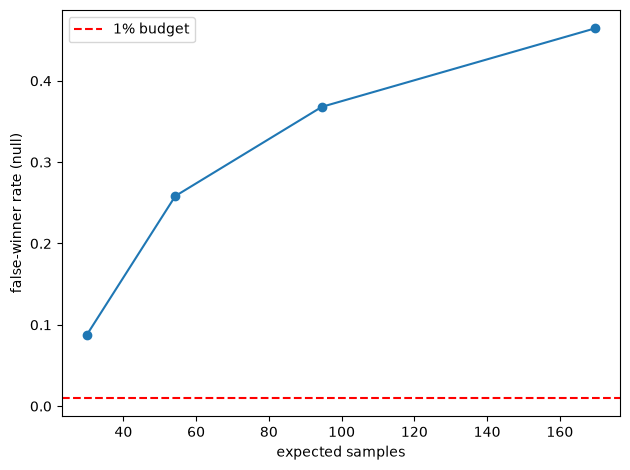

In [5]:
from bayesbench.calibration import simulate_pairwise

points = []
for max_s in (30, 60, 120, 250):
    r = simulate_pairwise(n=3000, true_acc_a=0.5, true_acc_b=0.5,
                         confidence=0.95, skip_threshold=1.0,
                         min_samples=30, max_samples=max_s, rng=42)
    total = sum(r[k] for k in ("winner_a", "winner_b", "skipped", "inconclusive"))
    points.append((max_s, r["false_decisions"] / total,
                   np.mean(r["samples_drawn"])))

for max_s, false, es in points:
    print(f"max={max_s:>3}: false {false:.1%}, E[samples] {es:.1f}")

plt.plot([p[2] for p in points], [p[1] for p in points], "o-")
plt.axhline(0.01, color="r", ls="--", label="1% budget")
plt.xlabel("expected samples")
plt.ylabel("false-winner rate (null)")
plt.legend()
plt.tight_layout()
plt.show()

# The false rate grows with the horizon (~9% at 30, ~46% at 250):
# the threshold rule's random walk eventually crosses 0.95 under
# the null, so a 1% budget does not exist at any of these
# horizons. Hard error budgets need the confidence-sequence rule.

## Exercise 5 — The price of a guarantee

Reproduce the Section 4 confidence-sequence table for `alpha=0.01` (instead of 0.05). For each gap, report the any-time false rate, correct rate, and expected samples. How many extra samples does the tighter guarantee cost?

**Solution**

In [6]:
for acc_a, acc_b in ((0.50, 0.50), (0.90, 0.50)):
    r = simulate_pairwise_cs(n=1200, true_acc_a=acc_a, true_acc_b=acc_b,
                            alpha=0.01, max_samples=200, rng=42)
    total = sum(r[k] for k in ("winner_a", "winner_b", "equivalent", "inconclusive"))
    correct = r["winner_a"] / total if acc_a > acc_b else 0.0
    print(f"gap {acc_a - acc_b:+.2f}: false {r['false_decisions'] / total:.2%}, "
          f"correct {correct:.1%}, inconclusive {r['inconclusive'] / total:.1%}, "
          f"E[samples] {np.mean(r['samples_drawn']):.1f}")

# alpha=0.01 shrinks the per-side budget to 0.005, widening the
# confidence sequences: for gap 0.40 the expected sample count
# rises from ~54 (alpha=0.05) to ~70. Roughly a third more
# samples for a 5x tighter guarantee.

gap +0.00: false 0.00%, correct 0.0%, inconclusive 100.0%, E[samples] 200.0


gap +0.40: false 0.00%, correct 100.0%, inconclusive 0.0%, E[samples] 70.7


## Exercise 6 — Pairing

Build two *different* solvers with the same accuracy (`noisy_solver(..., variant="a")` and `variant="b"`, both at 0.55) and run `paired=True` vs `paired=False` with `equivalence_margin=0.05` on the 2000-problem dataset. What decision does each reach, and what does `paired=True` actually change in the statistical model?

**Solution**

In [7]:
for paired in (False, True):
    bench = BayesianBenchmark(confidence=0.95, paired=paired,
                              equivalence_margin=0.05)
    res = bench.compare(lambda p: noisy_solver(p, accuracy=0.55, variant="a"),
                        lambda p: noisy_solver(p, accuracy=0.55, variant="b"),
                        exact_match, big)
    print(f"paired={paired}: {res.decision.value} after {res.problems_tested}")

# Both configurations declare the solvers equivalent. The
# difference is the model: paired=True builds ONE posterior over
# per-item score differences (for binary data: the win/loss rate
# on discordant items only), so shared item difficulty cannot be
# double-counted as independent evidence. The calibration report
# shows why this matters: under correlated item difficulty the
# paired analysis cuts null false-decision rates roughly in half.

paired=False: equivalent after 766
paired=True: equivalent after 814
